# Import Libraries

In [1]:
import numpy as np
import cvxpy as cp
import sympy as sp
from sympy.physics.vector import dynamicsymbols
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt

# IEEE 14 bus network 
# to get test system
from pypower.api import case14, runpf, printpf, makeYbus
from pypower.idx_bus import *
from pypower.idx_brch import *
from pypower.idx_gen import *

# Helper functions
import helper_functions.inner_loop as il
import helper_functions.optimal_controller as oc
import helper_functions.multiple_inverter as mc
import helper_functions.plotting as plot
import helper_functions.droop_controller as dr

# Text display
from IPython.display import display, HTML, Math

# Initialize pretty printing with MathJax
sp.init_printing(use_latex="mathjax")

# Configure plot parameters
plt.rcParams.update({"font.size": 12, "font.family": "serif"})
dflt_figsize = (10.0, 6.0)
plt.rcParams['figure.figsize'] = dflt_figsize
plt.rcParams['figure.dpi'] = 200 
%matplotlib inline

In [2]:
S_rated = 1200 # VA/W
S_base = S_rated # for per unit (3 phase)
v_nom_val = 120 # V
V_base = v_nom_val # for per unit (LN, RMS)
f_nom_val = 60 # Hz
omega_nom_val = 2 * np.pi * f_nom_val # rad/s
i_nom_val = S_rated/(3*v_nom_val) 
I_base = S_base/(3*V_base) # for per unit (phase, RMS)
Z_base = V_base / I_base # for per unit

Imag_lim_val = i_nom_val
# Filter and line parameters
r_i_val, r_g_val = 0.4, 0.9
l_i_val, l_g_val =  1.5e-3, 2e-3 
c_val = 10e-7 
L = l_i_val+l_g_val
R = r_i_val+r_g_val
Vg = np.array([v_nom_val,0])
starttime = 0.05
endtime = 2

# Convert to pu
S_rated_pu = S_rated/S_base
v_nom_val_pu = v_nom_val / V_base
i_nom_val_pu = i_nom_val / I_base
Imag_lim_val_pu = i_nom_val_pu
r_i_val_pu, r_g_val_pu = r_i_val/Z_base, r_g_val/Z_base
l_i_val_pu, l_g_val_pu =  l_i_val/Z_base, l_g_val/Z_base # technically incorrect pu expression but works with code
c_val_pu = c_val * Z_base # (c_pu = c_val/Y_base = c_val * Z_base) # technically incorrect pu expression but works with code
L_pu = l_i_val_pu + l_g_val_pu
R_pu = r_i_val_pu + r_g_val_pu
Vg_pu = Vg / V_base

# A. Setpoint change (droop comparison)

## A.1 Outer Loop Only

In [3]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.75,0.3])
new_setpoints = [1, 1]
var_names = ["P",r"$V^2$"]

freq_outer = 100 #500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc = oc.oc_setpoint_change(new_setpoints, var_names, x0, R_pu, L_pu, Vg_pu,
                        Imag_lim_val_pu,omega_nom_val,
                        rho=rho,alpha=alpha, dt=dt, 
                        starttime=starttime, endtime=endtime, perunit=perunit)

ts_dr, Idq_of_t_dr, Vdqref_of_t_dr, Vdqactual_of_t_dr, P_of_t_dr, V2_of_t_dr, Vmag_of_t_dr, delta_of_t_dr = dr.pv2_droop_disturbance(new_setpoints, 
                        x0, R_pu, L_pu, Vg_pu, 
                        Imag_lim_val_pu, omega_nom_val, omega_c_val, m_p_val, m_v2_val,  
                        dt = dt, starttime = starttime, endtime=endtime, perunit=perunit, setpoint_change=True)


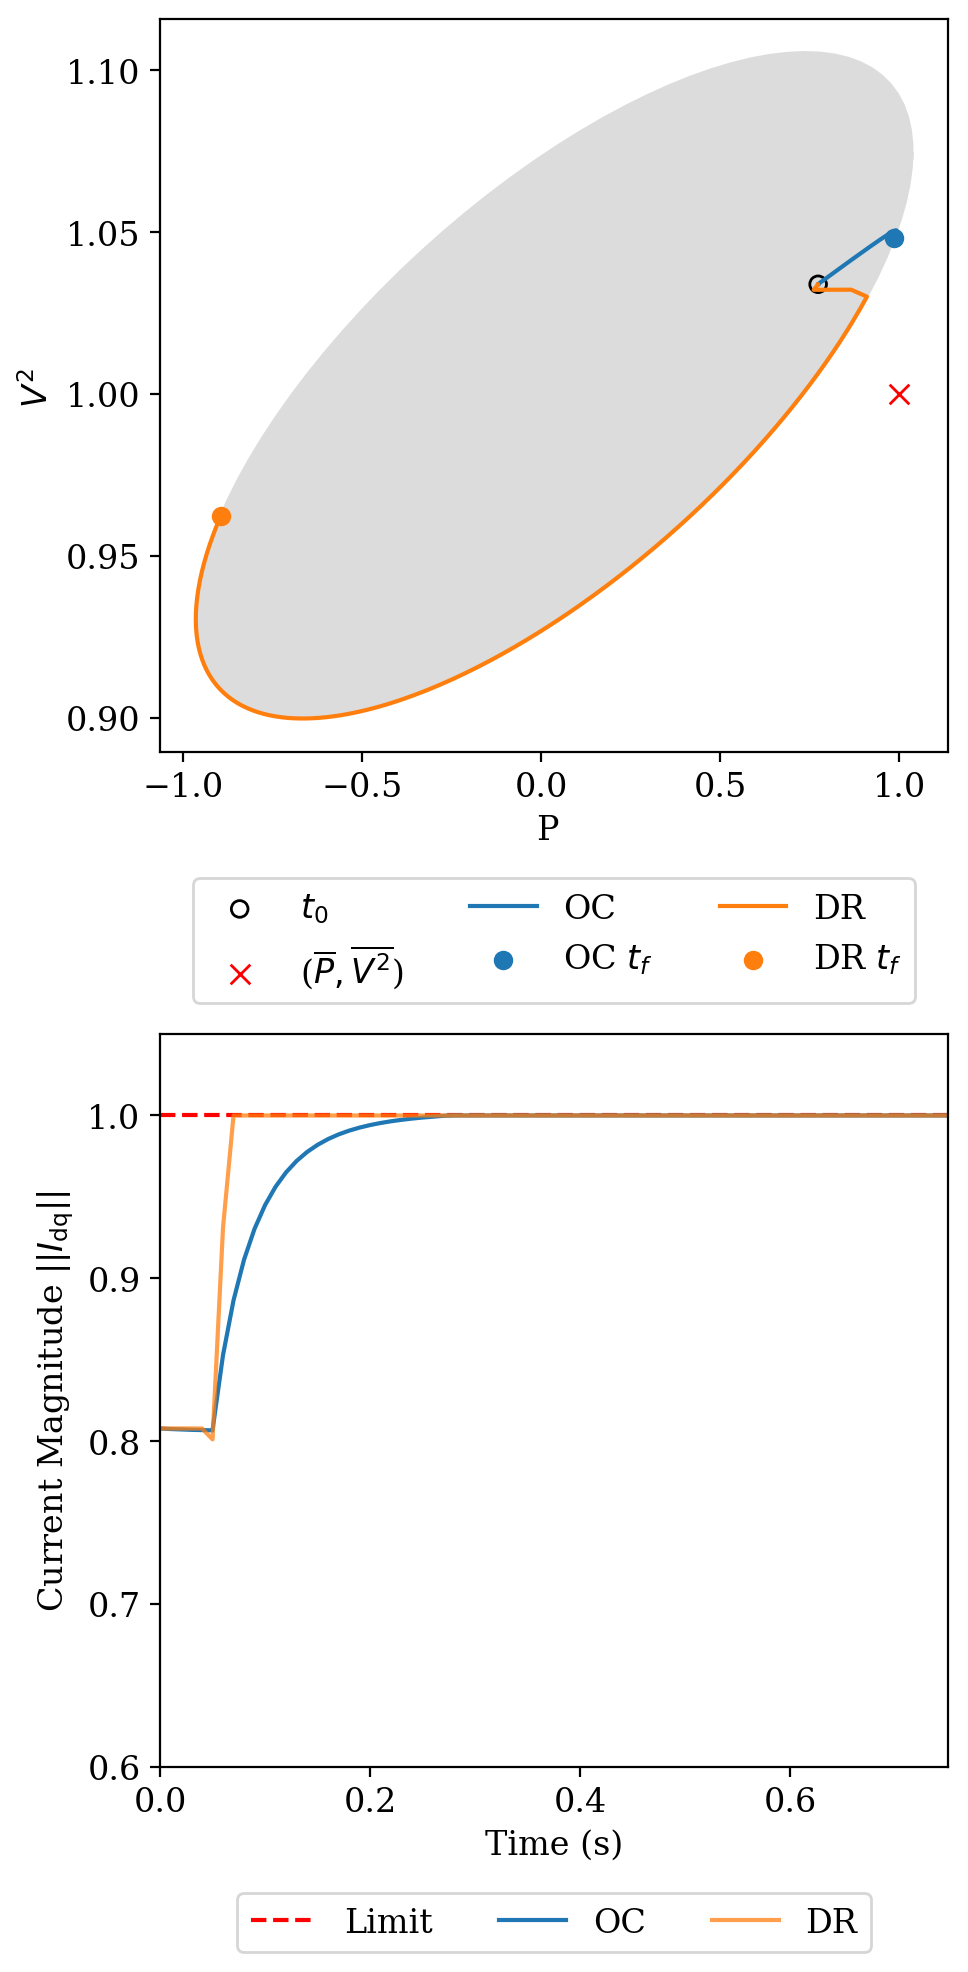

In [4]:
# HORIZONTAL: 
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))

# VERTICAL:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, new_setpoints,var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit, second_trajectory=np.vstack([P_of_t_dr,V2_of_t_dr]).T, two_traj_labels=["OC","DR"])

ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="DR",alpha=0.75)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_ylim([0,1.05])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Magnitude $||I_\mathrm{dq}||$")

# Zoom in 
ax2.set_xlim([0,0.75])
ax2.set_ylim([0.6,1.05])

plt.tight_layout()
plt.savefig("vert_setpoint_droop.png")

## A.2 Include inner loop dynamics

In [7]:
# Compare to same example above without inner loop dynamics
freq_vol = 600 #800
freq_cur = 2000 #3000

ts_inner, Idq_of_t_inner,Vdq_of_t_inner,var1_of_t_inner,var2_of_t_inner = oc.oc_setpoint_change_with_il(new_setpoints, var_names, x0, 
                               r_i_val_pu, l_i_val_pu, r_g_val_pu, l_g_val_pu, c_val_pu, Vg_pu,
                               Imag_lim_val_pu,omega_nom_val,
                               rho=0.001,alpha=alpha, dt=1/freq_outer, 
                               starttime=starttime, endtime=endtime/2,
                               freq_cur=freq_cur, freq_vol=freq_vol, perunit=perunit)

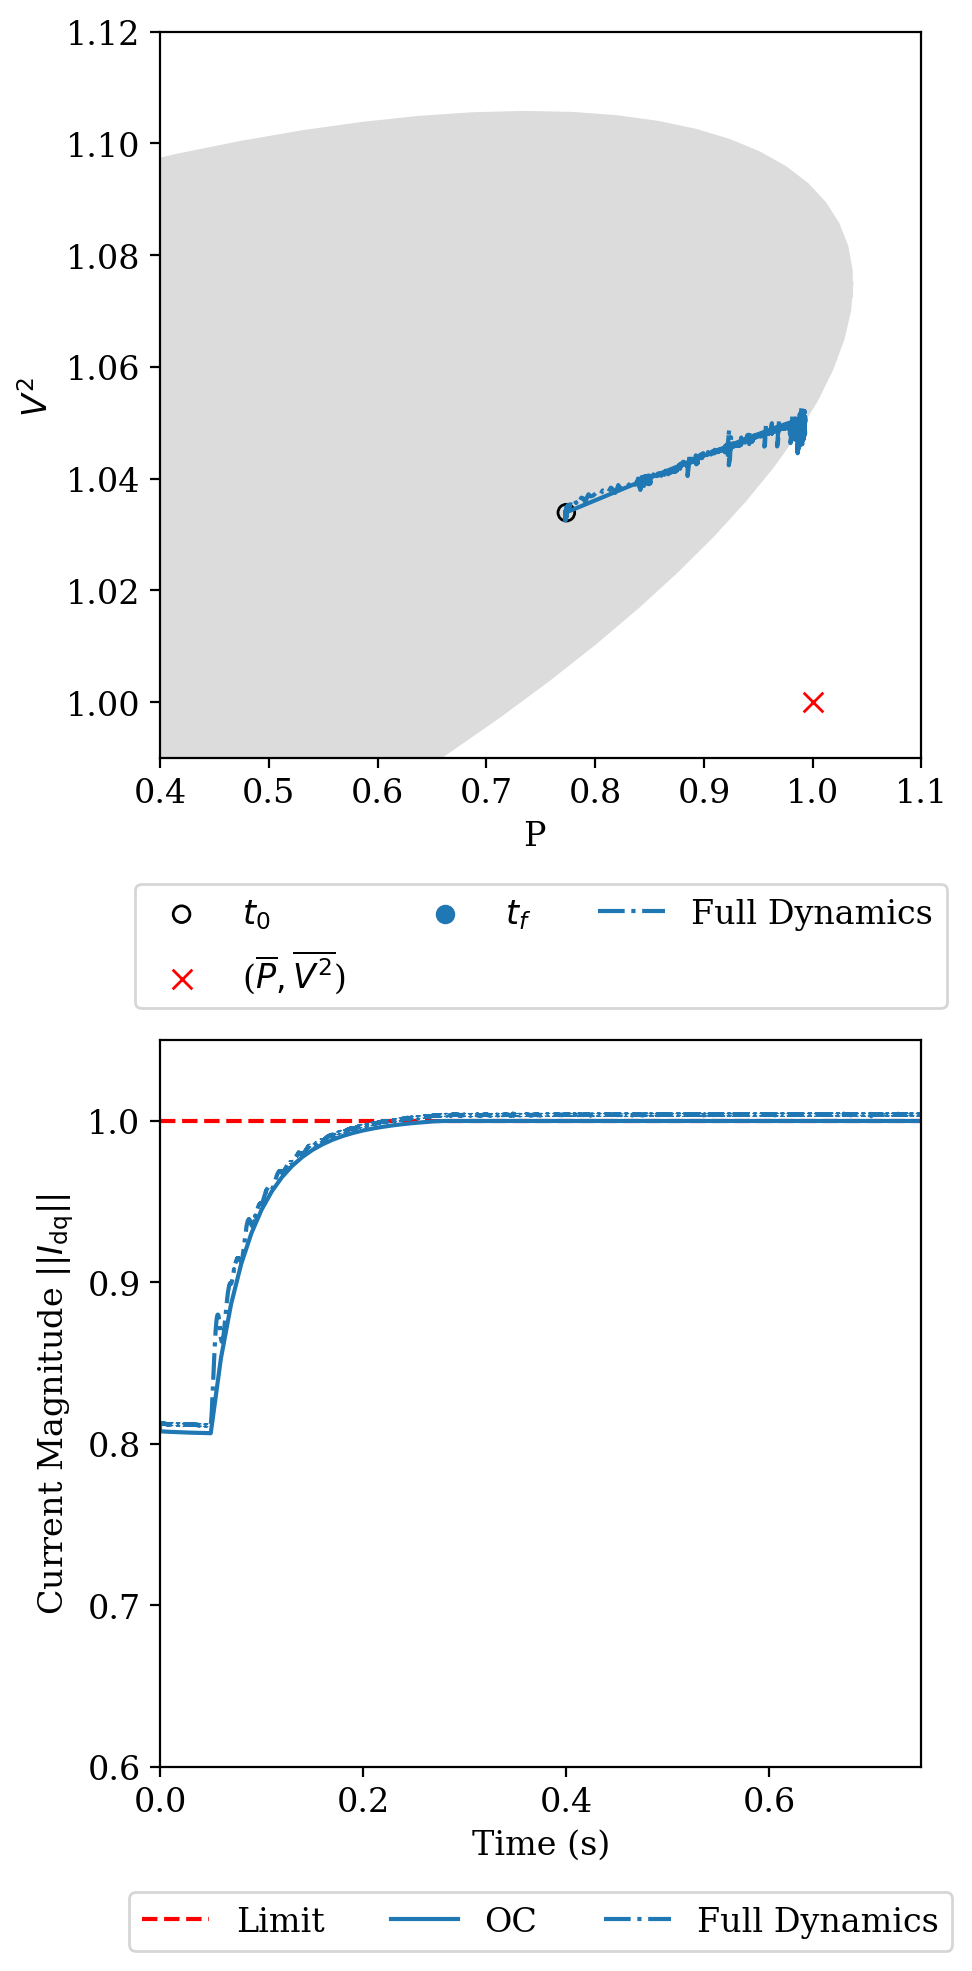

In [8]:
# Horizontal
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))

# Vertical
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, new_setpoints,var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit)
ax1.plot(var1_of_t_inner,var2_of_t_inner,c="C0",linestyle="-.",label="Full Dynamics")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)

ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_inner, np.linalg.norm(Idq_of_t_inner,axis=0),c='C0',linestyle="-.",label="Full Dynamics")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_ylim([0,1.05])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Magnitude $||I_\mathrm{dq}||$")

# Zoomed in view
ax1.set_xlim([0.4,1.1])
ax1.set_ylim([0.99,1.12])

# Zoom in 
ax2.set_xlim([0,0.75])
ax2.set_ylim([0.6,1.05])

plt.tight_layout()
plt.savefig("vert_setpoint_innerloop.png")


# B. Step change in grid voltage (droop comparison)

In [11]:
# P, V^2 Tracking
perunit=True
x0 = np.array([0.9,0.0])
Vg_newmag_pu = v_nom_val_pu * 0.83
new_setpoints = [Vg_newmag_pu, 0]
var_names = ["P",r"$V^2$"]

freq_outer = 100#500
dt = 1/freq_outer

# OC parameters
alpha = 1
rho = 0.001

# Droop parameters
omega_c_val = 30 # Hz
m_p_val = 0.5 * 2 * np.pi # 0.5 Hz frequency droop 
m_v2_val = 0.05 # 5% voltage droop


ts_oc, Idq_of_t_oc,Vdq_of_t_oc,var1_of_t_oc,var2_of_t_oc, Vg_of_t_oc = oc.oc_Edq_change(Vg_newmag_pu, var_names, x0,R_pu,L_pu,v_nom_val_pu, 
                  Imag_lim_val_pu,omega_nom_val,variance_size = 0.1,
                  rho=rho,alpha=alpha, dt=dt, 
                  starttime = starttime, endtime=endtime, perunit=perunit)

ts_dr, Idq_of_t_dr, Vdqref_of_t_dr, Vdqactual_of_t_dr, P_of_t_dr, V2_of_t_dr, Vmag_of_t_dr, delta_of_t_dr = dr.pv2_droop_disturbance(new_setpoints, 
                        x0, R_pu, L_pu, Vg_pu, 
                        Imag_lim_val_pu, omega_nom_val, omega_c_val, m_p_val, m_v2_val,  
                        dt = dt, starttime = starttime, endtime=endtime, perunit=perunit, setpoint_change=False)


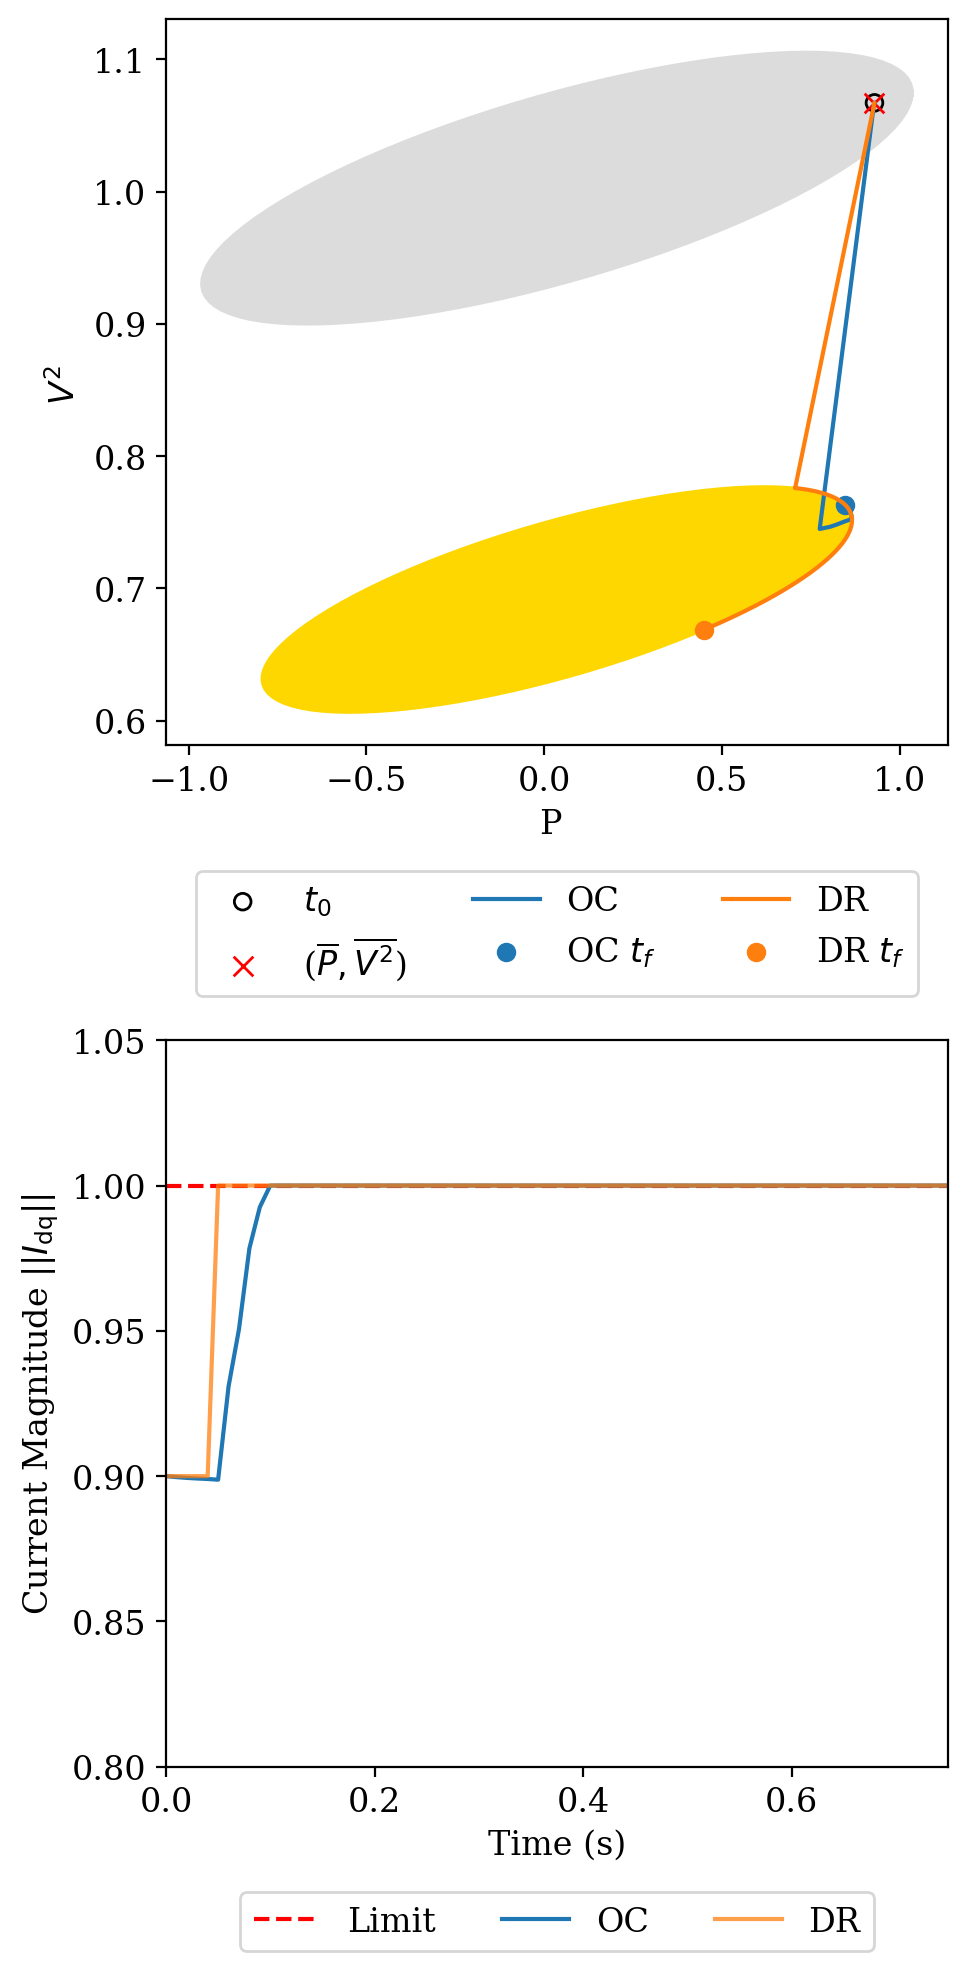

In [12]:
# fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(5,10))
disturbed_region_data = plot.set_S(var_names,Imag_lim_val_pu,Vg_newmag_pu,L_pu,R_pu,omega_nom_val,pu=perunit)
ax1.fill(disturbed_region_data[:,0],disturbed_region_data[:,1],c="gold")

plot.plot_S(np.vstack([var1_of_t_oc,var2_of_t_oc]).T, [var1_of_t_oc[0],var2_of_t_oc[0]],var_names, 
           Imag_lim_val_pu,v_nom_val_pu,L_pu,R_pu,omega_nom_val, 
           units = ["",""], ax = ax1, pu=perunit, second_trajectory=np.vstack([P_of_t_dr,V2_of_t_dr]).T, two_traj_labels=["OC","DR"])

ax2.plot(ts_oc, np.ones(len(ts_oc))*Imag_lim_val_pu,'r--',label="Limit")
ax2.plot(ts_oc, np.linalg.norm(Idq_of_t_oc,axis=0),c='C0',label="OC")
ax2.plot(ts_dr, np.linalg.norm(Idq_of_t_dr,axis=0),c='C1',label="DR",alpha=0.75)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),ncol=3)
ax2.set_ylim([0,1.05])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Current Magnitude $||I_\mathrm{dq}||$")

ax2.set_xlim([0,0.75])
ax2.set_ylim([0.8,1.05])

plt.tight_layout()
plt.savefig("vert_voltstep_droop.png")

# C. Setpoint change in 14 bus (reduced) network

### 1. Load 14 bus test system and run powerflow

In [13]:
net14 = case14()
base_mva = net14["baseMVA"]
nb = net14["bus"].shape[0]
nbr = net14["branch"].shape[0]
# Initialize "inverters" at non-zero power before solving powerflow
net14["gen"][:,PG] = np.array([60,90,90,90,90])

# Find equilibrium point (run power flow) to initialize simulation
pf_result, success = runpf(net14)

PYPOWER Version 5.1.18, 10-Apr-2025 -- AC Power Flow (Newton)


Newton's method power flow converged in 4 iterations.

Converged in 0.01 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses             14     Total Gen Capacity     772.4         -52.0 to 148.0
Generators         5     On-line Capacity       772.4         -52.0 to 148.0
Committed Gens     5     Generation (actual)    261.9              59.2
Loads             11     Load                   259.0              73.5
  Fixed           11       Fixed                259.0              73.5
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             1     Shunt (inj)             -0.0              21.2
Branches          20     Losses (I^2 * Z)         2.94             31.56
Transformers       3     Branch 

### 2. Choose inverter filter parameters

In [14]:
inverter_bus_ids = np.array(net14["gen"][:,GEN_BUS],dtype=int)
slack_id = inverter_bus_ids[0]
inverter_bus_ids = inverter_bus_ids[1:]
filter_xs = np.ones(len(inverter_bus_ids)) * 0.1 # in per unit
filter_rs = np.ones(len(inverter_bus_ids)) * 0.01 # in per unit


### 3. Construct Ybus matrix

In [15]:
Ybus = mc.create_Ybus(net14, pf_result)
Ybus_KRONdq, Y_slackdq = mc.Kron_reduce(Ybus, slack_id-1, inverter_bus_ids-1)

### 4. Simulate

#### Example: Increase power setpoint for inverter 1 to violate current limit

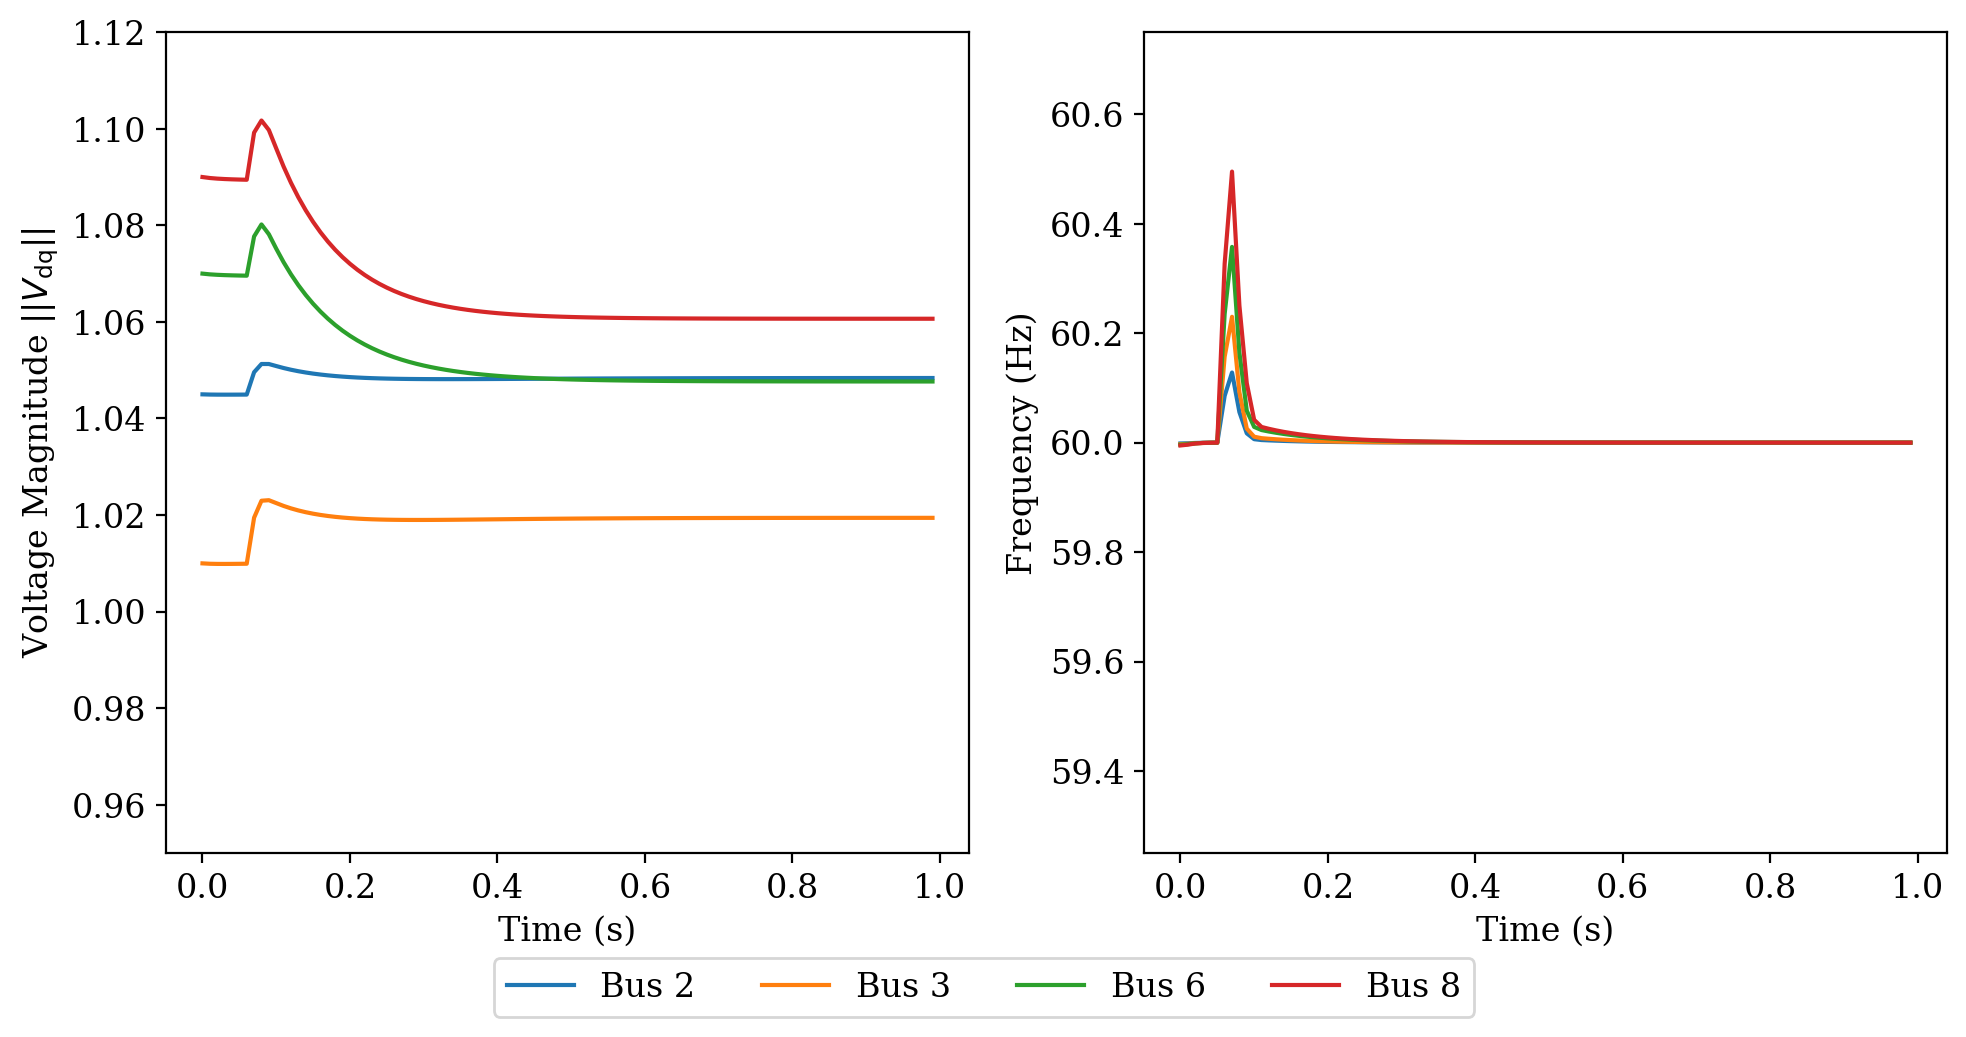

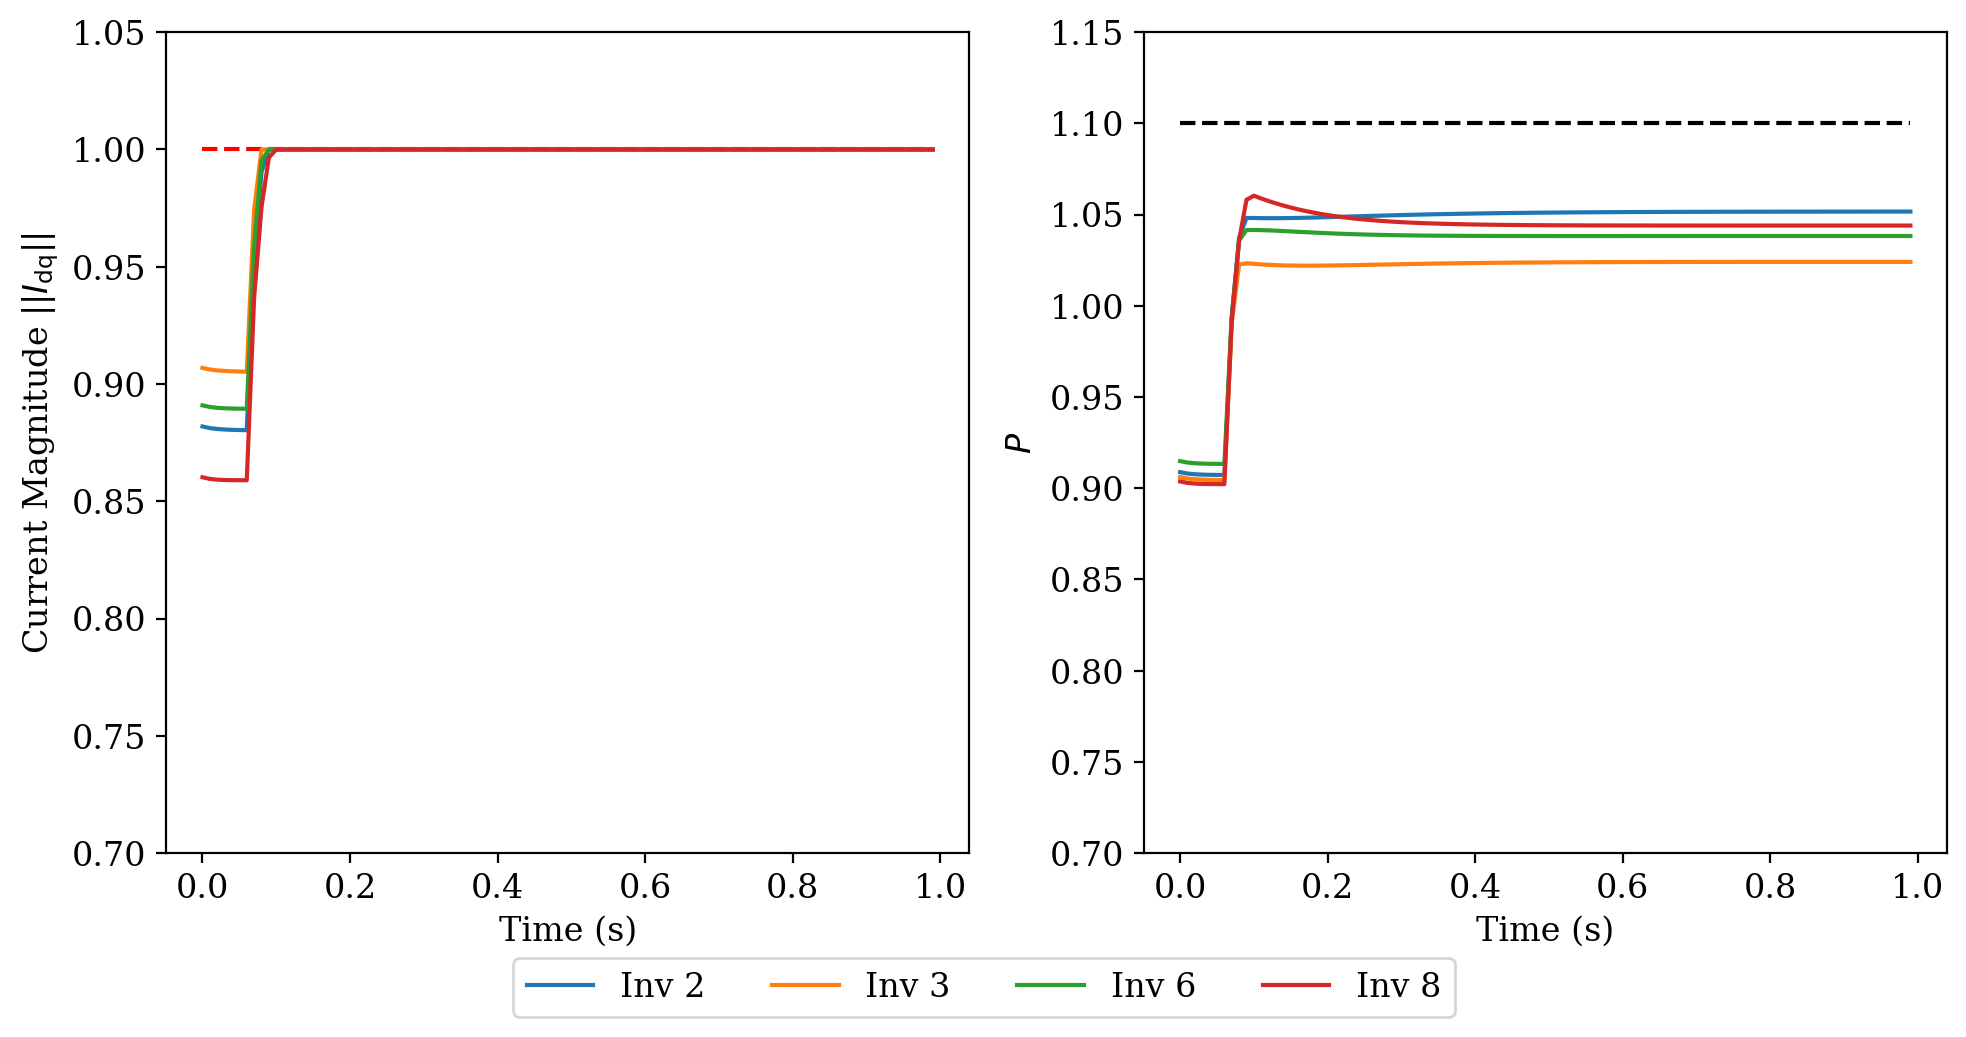

In [16]:
starttime=0.05
endtime = 1
dt = 1e-2
rho = 0.001
alpha = 2

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,0] = 1.1 * np.ones(len(Ps0))
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

bus_labels = np.array([2,3,6,8]) # the bus IDs for the inverters

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, r"Voltage Magnitude $||V_\mathrm{dq}||$", "Bus", xlim=None, inv_labels = bus_labels, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency (Hz)", "Bus", xlim=None, inv_labels = bus_labels, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
ax1.set_ylim([0.95,1.12])
ax2.set_ylim([59.25,60.75])
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "r--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, r"Current Magnitude $||I_\mathrm{dq}||$", "Inv", inv_labels = bus_labels, xlim=None, ax=ax1, show_legend=False)
ax2.plot(ts, inverter_setpoints[0,0] * np.ones(len(ts)), "k--") # Plot power setpoint 
plot.plot_multi_inverters(ts, Ps, r"$P$", "Inv", xlim=None, ax=ax2, inv_labels = bus_labels, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
ax1.set_ylim([0.7,1.05])
ax2.set_ylim([0.7,1.15])
plt.tight_layout()
plt.show()

#### Same example with slower dt

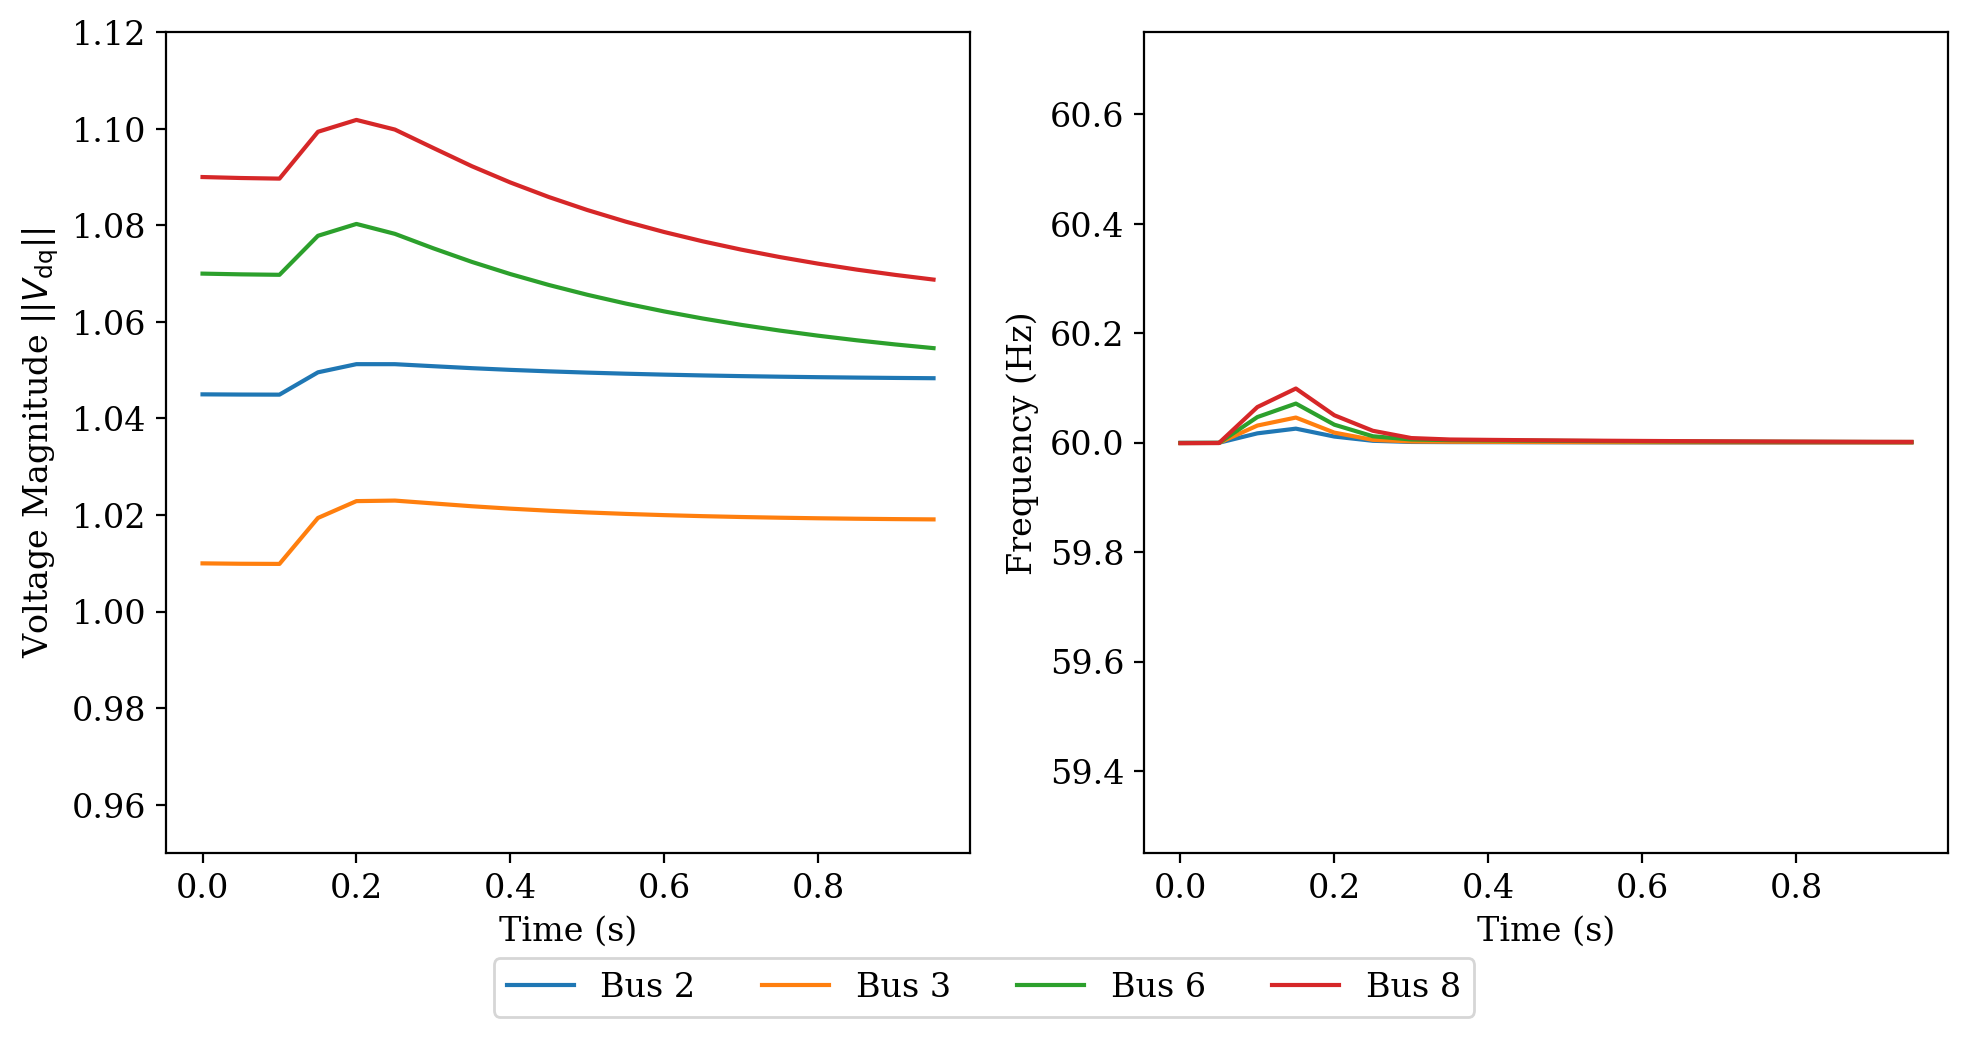

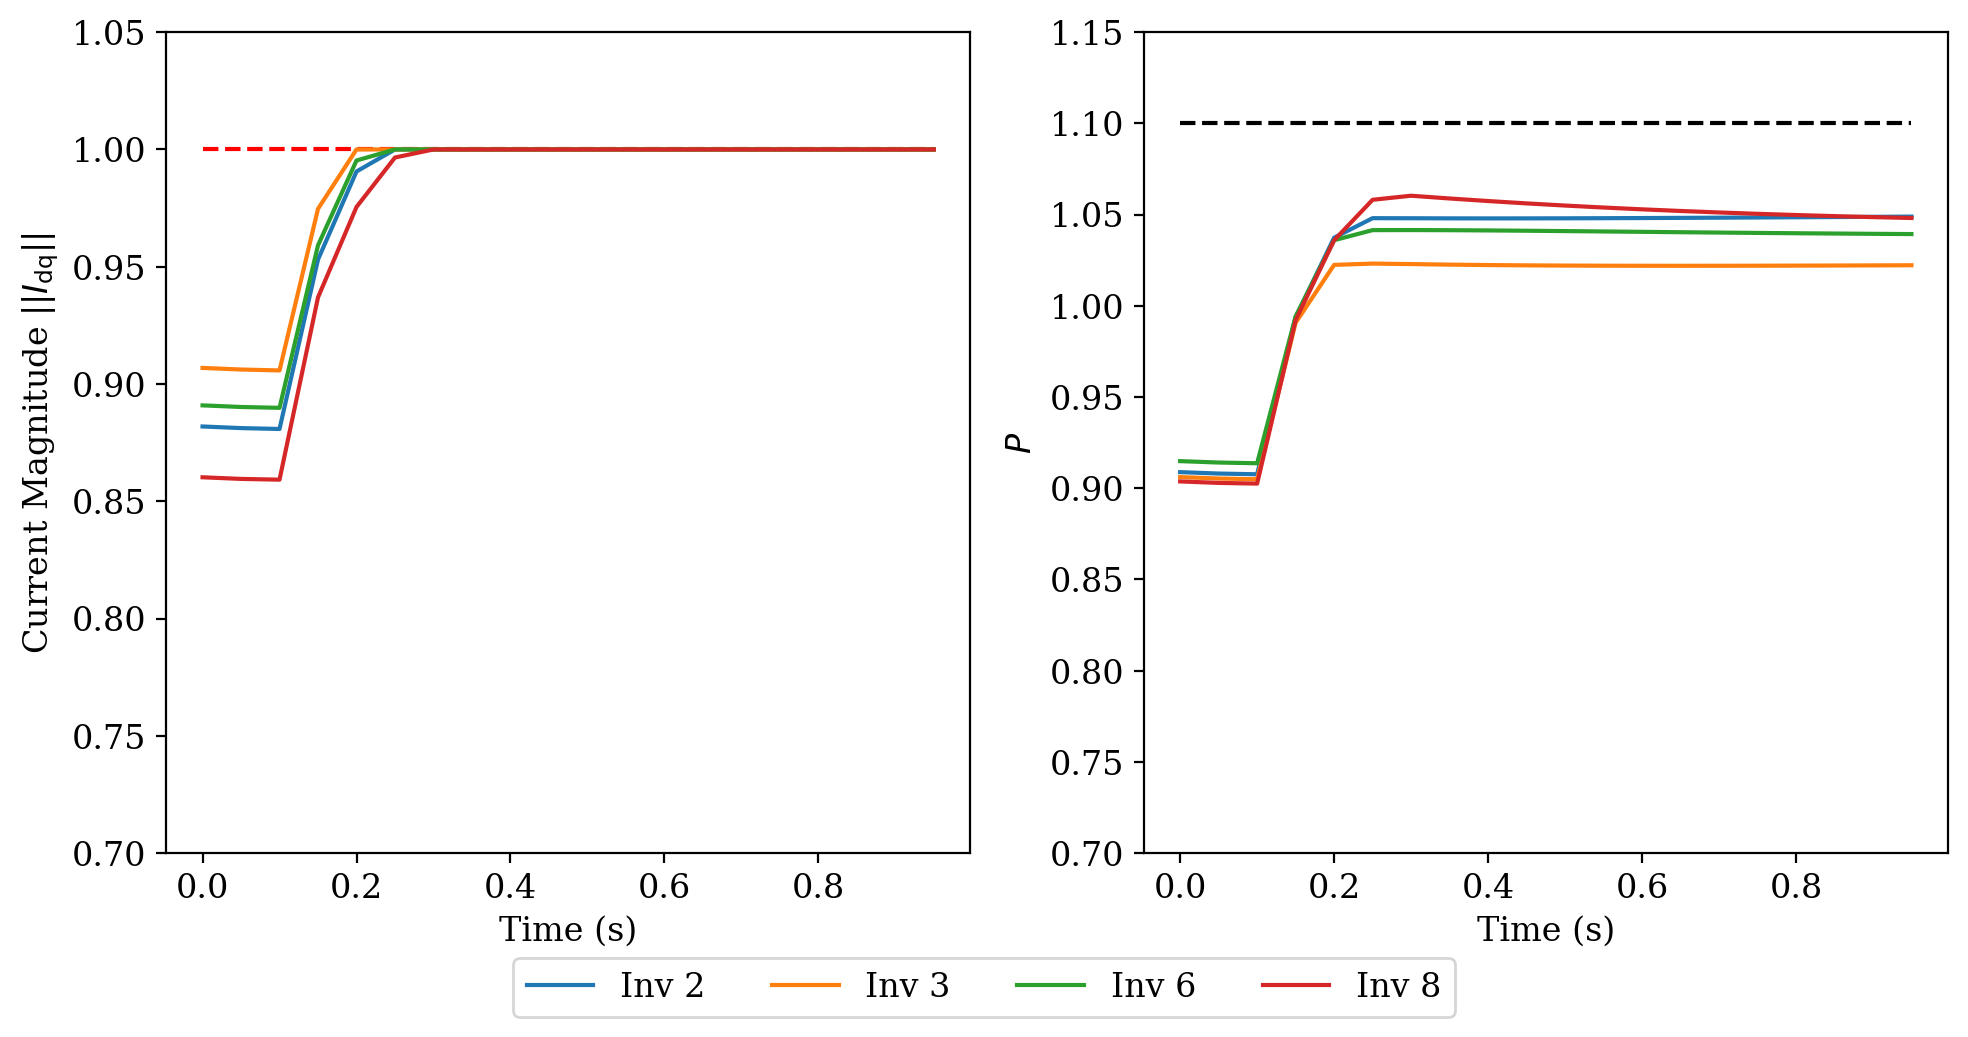

In [11]:
starttime=0.05
endtime = 1
dt = 5e-2
rho = 0.001
alpha = 2

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,0] = 1.1 * np.ones(len(Ps0))
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, r"Voltage Magnitude $||V_\mathrm{dq}||$", "Bus", xlim=None, inv_labels = bus_labels, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency (Hz)", "Bus", xlim=None, inv_labels = bus_labels, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
ax1.set_ylim([0.95,1.12])
ax2.set_ylim([59.25,60.75])
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "r--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, r"Current Magnitude $||I_\mathrm{dq}||$", "Inv", inv_labels = bus_labels, xlim=None, ax=ax1, show_legend=False)
ax2.plot(ts, inverter_setpoints[0,0] * np.ones(len(ts)), "k--") # Plot power setpoint 
plot.plot_multi_inverters(ts, Ps, r"$P$", "Inv", xlim=None, ax=ax2, inv_labels = bus_labels, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
ax1.set_ylim([0.7,1.05])
ax2.set_ylim([0.7,1.15])
plt.tight_layout()
plt.show()